In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [2]:
param_name = 'chargeSpeed'
expt_type = 'playfight/with_cover_story/sentiment_analyses/'
rootfile_loc = f'../../data/text_responses/{expt_type}'

df = pd.read_csv(f'{rootfile_loc}/data_with_sentiment_scores.csv', index_col=[0])
df = df.reset_index()
df

,index,subID,stimset_rows,chargeSpeed,responses,movie,trial_num,neg_score,neu_score,pos_score,pos-neg,pos-neu,neg-neu,neu-neg
0,2,24058,96,1.5,talking and exploring the park,e5e05e73-9cd0-4990-8da2-4962e0a03e5d,2,0.008222,0.446902,0.544876,0.536654,0.097974,-0.438680,0.438680
1,0,24075,46,1.5,playing together,50919f52-6a9c-4824-b24f-2f1aebd58e1b,0,0.008245,0.894250,0.097505,0.089260,-0.796744,-0.886004,0.886004
2,6,24017,31,1.5,the dots were gently bumping into each other r...,95aaf072-b6be-4da4-9857-deaf20ab49f2,6,0.008893,0.258820,0.732287,0.723394,0.473467,-0.249927,0.249927
3,1,24026,3,1.5,The dots were coming together in a more friend...,15dfbaca-4429-4c18-90f4-8d4804129e6f,1,0.011655,0.566310,0.422035,0.410380,-0.144275,-0.554655,0.554655
4,3,24083,7,1.5,Walking around before getting called to walk a...,38ad4b16-44e2-4e52-8d02-b23eca73a48d,3,0.011682,0.938487,0.049831,0.038148,-0.888656,-0.926804,0.926804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,4,24000,22,9.0,Hit and run away.,a5228b86-ba0a-42f2-aa38-23b5369f0e56,4,0.340505,0.582922,0.076574,-0.263931,-0.506348,-0.242417,0.242417
701,1,24037,65,9.0,body slamming,5b2465b2-47b6-4cc7-b06f-c362ff7454f8,1,0.405213,0.468791,0.125996,-0.279217,-0.342795,-0.063578,0.063578
702,4,24001,5,9.0,aggressively charging at each other,87da47db-3d5c-48b2-b3f2-123123d766f0,4,0.418659,0.499900,0.081441,-0.337217,-0.418458,-0.081241,0.081241
703,2,24006,52,9.0,running at each other,9f7e489f-4076-4332-b57e-13a42d4c75fd,2,0.435876,0.483708,0.080415,-0.355461,-0.403293,-0.047832,0.047832


In [3]:
import matplotlib.pyplot as plt
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [4]:
param_name = 'chargeSpeed'

In [5]:
results_dir = '../../results/text_analysis/pf/with_cover_story/'

In [6]:
colors_plot = 'tab:red'

In [7]:
# pip install nltk


In [8]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/f0053cz/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [9]:
# Load NRC VAD (CSV format: word,valence,arousal,dominance)
vad = pd.read_csv("./NRC-VAD-Lexicon-v2.1/NRC-VAD-Lexicon-v2.1.txt", sep="\t")
vad_dict = dict(zip(vad['term'], vad['arousal']))
vad_dict_valence = dict(zip(vad['term'], vad['valence']))

# def compute_arousal(text):
#     tokens = word_tokenize(text.lower())
#     scores = [vad_dict[word] for word in tokens if word in vad_dict]
#     return sum(scores) / len(scores) if scores else None

import re

def compute_arousal(text):
    tokens = re.findall(r'\b\w+\b', text.lower())
    print(tokens)
    scores = [vad_dict[word] for word in tokens if word in vad_dict]
    print(scores)
    return sum(scores) / len(scores) if scores else None


def compute_valence(text):
    tokens = re.findall(r'\b\w+\b', text.lower())
    print(tokens)
    scores = [vad_dict_valence[word] for word in tokens if word in vad_dict_valence]
    print(scores)
    return sum(scores) / len(scores) if scores else None


In [10]:
vad.sort_values(by='arousal', ascending=False).head(10)

,term,valence,arousal,dominance
16695,explosively,-0.111,1.0,0.815
2277,ardently,1.000,1.0,0.296
29718,maul,-0.667,1.0,0.704
2330,armageddon,-1.000,1.0,0.833
49950,turbocharger,0.667,1.0,0.778
36721,popeyed,-0.333,1.0,0.000
45444,stabber,-1.000,1.0,0.905
45445,stabbing,-0.810,1.0,-0.370
49350,traindriver,0.000,1.0,0.625
49951,turbojet,0.278,1.0,0.963


In [11]:
vad.sort_values(by='arousal', ascending=True).head(10)

,term,valence,arousal,dominance
25683,insubstantiality,-0.619,-1.0,-0.926
23901,ignorable,-0.333,-1.0,-0.810
23871,idly,0.000,-1.0,-0.519
51065,unfrequented,-0.333,-1.0,-0.476
37177,predestination,0.000,-1.0,-0.167
23797,iciness,-0.389,-1.0,-0.125
51079,unfussy,0.583,-1.0,0.222
23781,icecap,0.222,-1.0,0.095
23778,icebound,-0.458,-1.0,-0.333
23745,hypothyroidism,-0.750,-1.0,-0.519


In [12]:
nltk.download('punkt', download_dir='/tmp/nltk_data')
import os
nltk.data.path.append('/tmp/nltk_data')


[nltk_data] Downloading package punkt to /tmp/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [13]:
text = "activated"
arousal_score = compute_arousal(text)
print(arousal_score)

['activated']
[1.0]
1.0


In [14]:
text = "abominableness"
arousal_score = compute_arousal(text)
print(arousal_score)

['abominableness']
[-0.667]
-0.667


In [15]:
text = "peaceful place"
arousal_score = compute_arousal(text)
print(arousal_score)

['peaceful', 'place']
[-0.892, -0.478]
-0.685


In [16]:
text = "very exciting"
arousal_score = compute_arousal(text)
print(arousal_score)

['very', 'exciting']
[0.0, 0.584]
0.292


In [17]:
text = "horrible explosion"
arousal_score = compute_arousal(text)
print(arousal_score)

['horrible', 'explosion']
[0.714, 0.96]
0.837


In [18]:
text = "The explosion was terrifying and loud."
arousal_score = compute_arousal(text)
print(arousal_score)


['the', 'explosion', 'was', 'terrifying', 'and', 'loud']
[0.96, -0.083, 0.672, 0.0, 0.3]
0.3698


# with cover story

In [19]:
df['arousal_score'] = df['responses'].apply(compute_arousal)
df

['talking', 'and', 'exploring', 'the', 'park']
[0.0, -0.314]
['playing', 'together']
[-0.216]
['the', 'dots', 'were', 'gently', 'bumping', 'into', 'each', 'other', 'repeatedly', 'much', 'gentler', 'than', 'before']
[0.0, -0.49, 0.0, 0.0, -0.54, 0.15, 0.0, -0.258]
['the', 'dots', 'were', 'coming', 'together', 'in', 'a', 'more', 'friendly', 'was']
[0.0, -0.166, -0.216, 0.0, -0.204, -0.083]
['walking', 'around', 'before', 'getting', 'called', 'to', 'walk', 'and', 'meet', 'in', 'a', 'centre', 'point']
[-0.04, -0.242, -0.258, 0.667, 0.0, -0.176, 0.0, 0.02, -0.194, -0.614]
['moving', 'nw', 'and', 'slowly', 'meeting']
[0.346, 0.0, -0.63, 0.138]
['going', 'to', 'the', 'movies']
[0.708, 0.0, -0.148]
['greeting', 'each', 'other']
[0.112, 0.0, -0.54]
['they', 'are', 'calmer', 'this', 'time', 'i', 'would', 'say', 'they', 'are', 'playing', 'together']
[0.0, 0.0, 0.0, -0.424, -0.176, -0.38, 0.0, 0.0, -0.216]
['coming', 'together', 'softly']
[-0.166, -0.216, -0.588]
['meeting', 'and', 'bouncing']
[0.

,index,subID,stimset_rows,chargeSpeed,responses,movie,trial_num,neg_score,neu_score,pos_score,pos-neg,pos-neu,neg-neu,neu-neg,arousal_score
0,2,24058,96,1.5,talking and exploring the park,e5e05e73-9cd0-4990-8da2-4962e0a03e5d,2,0.008222,0.446902,0.544876,0.536654,0.097974,-0.438680,0.438680,-0.15700
1,0,24075,46,1.5,playing together,50919f52-6a9c-4824-b24f-2f1aebd58e1b,0,0.008245,0.894250,0.097505,0.089260,-0.796744,-0.886004,0.886004,-0.21600
2,6,24017,31,1.5,the dots were gently bumping into each other r...,95aaf072-b6be-4da4-9857-deaf20ab49f2,6,0.008893,0.258820,0.732287,0.723394,0.473467,-0.249927,0.249927,-0.14225
3,1,24026,3,1.5,The dots were coming together in a more friend...,15dfbaca-4429-4c18-90f4-8d4804129e6f,1,0.011655,0.566310,0.422035,0.410380,-0.144275,-0.554655,0.554655,-0.11150
4,3,24083,7,1.5,Walking around before getting called to walk a...,38ad4b16-44e2-4e52-8d02-b23eca73a48d,3,0.011682,0.938487,0.049831,0.038148,-0.888656,-0.926804,0.926804,-0.08370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,4,24000,22,9.0,Hit and run away.,a5228b86-ba0a-42f2-aa38-23b5369f0e56,4,0.340505,0.582922,0.076574,-0.263931,-0.506348,-0.242417,0.242417,0.28800
701,1,24037,65,9.0,body slamming,5b2465b2-47b6-4cc7-b06f-c362ff7454f8,1,0.405213,0.468791,0.125996,-0.279217,-0.342795,-0.063578,0.063578,0.46100
702,4,24001,5,9.0,aggressively charging at each other,87da47db-3d5c-48b2-b3f2-123123d766f0,4,0.418659,0.499900,0.081441,-0.337217,-0.418458,-0.081241,0.081241,0.07800
703,2,24006,52,9.0,running at each other,9f7e489f-4076-4332-b57e-13a42d4c75fd,2,0.435876,0.483708,0.080415,-0.355461,-0.403293,-0.047832,0.047832,0.04400


In [20]:
df['valence_score_again'] = df['responses'].apply(compute_valence)
df

['talking', 'and', 'exploring', 'the', 'park']
[0.0, 0.632]
['playing', 'together']
[0.748]
['the', 'dots', 'were', 'gently', 'bumping', 'into', 'each', 'other', 'repeatedly', 'much', 'gentler', 'than', 'before']
[0.0, 0.834, 0.0, 0.125, -0.056, -0.042, 0.0, -0.038]
['the', 'dots', 'were', 'coming', 'together', 'in', 'a', 'more', 'friendly', 'was']
[0.0, 0.306, 0.748, 0.667, 0.834, 0.0]
['walking', 'around', 'before', 'getting', 'called', 'to', 'walk', 'and', 'meet', 'in', 'a', 'centre', 'point']
[0.416, 0.034, -0.038, 0.167, 0.0, 0.286, 0.0, 0.52, 0.388, -0.02]
['moving', 'nw', 'and', 'slowly', 'meeting']
[-0.042, 0.0, -0.146, 0.5]
['going', 'to', 'the', 'movies']
[0.048, 0.0, 0.448]
['greeting', 'each', 'other']
[0.708, 0.125, -0.056]
['they', 'are', 'calmer', 'this', 'time', 'i', 'would', 'say', 'they', 'are', 'playing', 'together']
[0.0, 0.0, 0.0, 0.208, -0.014, 0.142, 0.0, 0.0, 0.748]
['coming', 'together', 'softly']
[0.306, 0.748, 0.034]
['meeting', 'and', 'bouncing']
[0.5, 0.0]


,index,subID,stimset_rows,chargeSpeed,responses,movie,trial_num,neg_score,neu_score,pos_score,pos-neg,pos-neu,neg-neu,neu-neg,arousal_score,valence_score_again
0,2,24058,96,1.5,talking and exploring the park,e5e05e73-9cd0-4990-8da2-4962e0a03e5d,2,0.008222,0.446902,0.544876,0.536654,0.097974,-0.438680,0.438680,-0.15700,0.316000
1,0,24075,46,1.5,playing together,50919f52-6a9c-4824-b24f-2f1aebd58e1b,0,0.008245,0.894250,0.097505,0.089260,-0.796744,-0.886004,0.886004,-0.21600,0.748000
2,6,24017,31,1.5,the dots were gently bumping into each other r...,95aaf072-b6be-4da4-9857-deaf20ab49f2,6,0.008893,0.258820,0.732287,0.723394,0.473467,-0.249927,0.249927,-0.14225,0.102875
3,1,24026,3,1.5,The dots were coming together in a more friend...,15dfbaca-4429-4c18-90f4-8d4804129e6f,1,0.011655,0.566310,0.422035,0.410380,-0.144275,-0.554655,0.554655,-0.11150,0.425833
4,3,24083,7,1.5,Walking around before getting called to walk a...,38ad4b16-44e2-4e52-8d02-b23eca73a48d,3,0.011682,0.938487,0.049831,0.038148,-0.888656,-0.926804,0.926804,-0.08370,0.175300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,4,24000,22,9.0,Hit and run away.,a5228b86-ba0a-42f2-aa38-23b5369f0e56,4,0.340505,0.582922,0.076574,-0.263931,-0.506348,-0.242417,0.242417,0.28800,-0.232000
701,1,24037,65,9.0,body slamming,5b2465b2-47b6-4cc7-b06f-c362ff7454f8,1,0.405213,0.468791,0.125996,-0.279217,-0.342795,-0.063578,0.063578,0.46100,-0.139500
702,4,24001,5,9.0,aggressively charging at each other,87da47db-3d5c-48b2-b3f2-123123d766f0,4,0.418659,0.499900,0.081441,-0.337217,-0.418458,-0.081241,0.081241,0.07800,-0.107750
703,2,24006,52,9.0,running at each other,9f7e489f-4076-4332-b57e-13a42d4c75fd,2,0.435876,0.483708,0.080415,-0.355461,-0.403293,-0.047832,0.047832,0.04400,0.132250


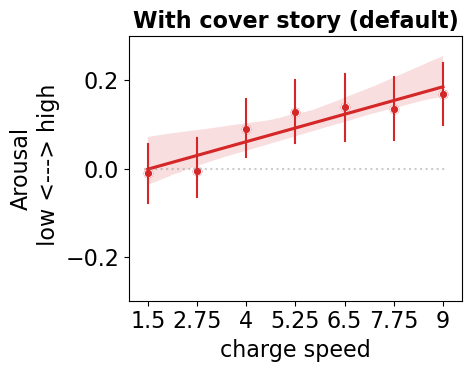

In [21]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(5,4), sharey=False,sharex=True)
sns.lineplot(data=df.reset_index(),x = param_name,y = 'arousal_score', ax=ax,marker = 'o', ls = 'None', color = colors_plot, err_style='bars')
sns.regplot(data = df[['arousal_score', param_name]].groupby([param_name]).mean().reset_index(),x = param_name, y='arousal_score',  ax=ax,marker = 'o', color=colors_plot)#,legend=False)
ax.set_title('With cover story (default)', fontweight = 'bold')
ax.set_ylabel('Arousal\n low <---> high')
ax.set_xlabel('charge speed')
ax.set_ylim(-.3,.3)
ax.hlines(0,1.4,9.1,color = 'grey',ls=':',alpha = .4)
ax.set_xticks(np.arange(1.5,9.1,1.25),['1.5','2.75','4','5.25','6.5','7.75','9'])
# ax.invert_xaxis()

plt.tight_layout()
plt.savefig(f'{results_dir}/arousal_analysis_withcoverstory.png',dpi=300,bbox_inches ='tight')

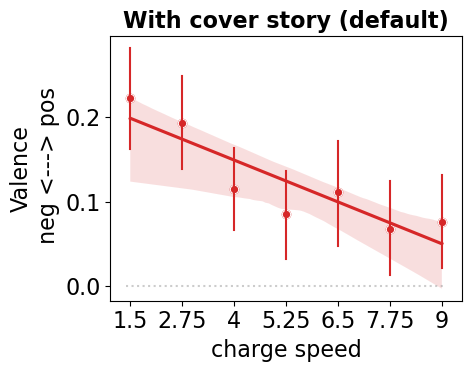

In [22]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(5,4), sharey=False,sharex=True)
sns.lineplot(data=df.reset_index(),x = param_name,y = 'valence_score_again', ax=ax,marker = 'o', ls = 'None', color = colors_plot, err_style='bars')
sns.regplot(data = df[['valence_score_again', param_name]].groupby([param_name]).mean().reset_index(),x = param_name, y='valence_score_again',  ax=ax,marker = 'o', color=colors_plot)#,legend=False)
ax.set_title('With cover story (default)', fontweight = 'bold')
ax.set_ylabel('Valence\n neg <---> pos')
ax.set_xlabel('charge speed')
# ax.set_ylim(-.2,.2)
ax.hlines(0,1.4,9.1,color = 'grey',ls=':',alpha = .4)
ax.set_xticks(np.arange(1.5,9.1,1.25),['1.5','2.75','4','5.25','6.5','7.75','9'])
# ax.invert_xaxis()

plt.tight_layout()
plt.savefig(f'{results_dir}/valence_analysis_again_withcoverstory.png',dpi=300,bbox_inches ='tight')

In [23]:
df = df.dropna(subset=['arousal_score','pos-neg'])
stats.pearsonr(df['arousal_score'], df['pos-neg'])

PearsonRResult(statistic=np.float64(0.2708466158384773), pvalue=np.float64(5.7085051237371516e-12))

In [25]:
stats.spearmanr(df['arousal_score'], df['pos-neg'], nan_policy='omit')

SignificanceResult(statistic=np.float64(0.2277718890920665), pvalue=np.float64(8.473297664472824e-09))

In [26]:
df['chargeSpeed'] = df['chargeSpeed'] - 1.5
df['chargeSpeed'] = df['chargeSpeed']/7.5
df

/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_56102/2900999163.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['chargeSpeed'] = df['chargeSpeed'] - 1.5
/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_56102/2900999163.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['chargeSpeed'] = df['chargeSpeed']/7.5


,index,subID,stimset_rows,chargeSpeed,responses,movie,trial_num,neg_score,neu_score,pos_score,pos-neg,pos-neu,neg-neu,neu-neg,arousal_score,valence_score_again
0,2,24058,96,0.0,talking and exploring the park,e5e05e73-9cd0-4990-8da2-4962e0a03e5d,2,0.008222,0.446902,0.544876,0.536654,0.097974,-0.438680,0.438680,-0.15700,0.316000
1,0,24075,46,0.0,playing together,50919f52-6a9c-4824-b24f-2f1aebd58e1b,0,0.008245,0.894250,0.097505,0.089260,-0.796744,-0.886004,0.886004,-0.21600,0.748000
2,6,24017,31,0.0,the dots were gently bumping into each other r...,95aaf072-b6be-4da4-9857-deaf20ab49f2,6,0.008893,0.258820,0.732287,0.723394,0.473467,-0.249927,0.249927,-0.14225,0.102875
3,1,24026,3,0.0,The dots were coming together in a more friend...,15dfbaca-4429-4c18-90f4-8d4804129e6f,1,0.011655,0.566310,0.422035,0.410380,-0.144275,-0.554655,0.554655,-0.11150,0.425833
4,3,24083,7,0.0,Walking around before getting called to walk a...,38ad4b16-44e2-4e52-8d02-b23eca73a48d,3,0.011682,0.938487,0.049831,0.038148,-0.888656,-0.926804,0.926804,-0.08370,0.175300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,4,24000,22,1.0,Hit and run away.,a5228b86-ba0a-42f2-aa38-23b5369f0e56,4,0.340505,0.582922,0.076574,-0.263931,-0.506348,-0.242417,0.242417,0.28800,-0.232000
701,1,24037,65,1.0,body slamming,5b2465b2-47b6-4cc7-b06f-c362ff7454f8,1,0.405213,0.468791,0.125996,-0.279217,-0.342795,-0.063578,0.063578,0.46100,-0.139500
702,4,24001,5,1.0,aggressively charging at each other,87da47db-3d5c-48b2-b3f2-123123d766f0,4,0.418659,0.499900,0.081441,-0.337217,-0.418458,-0.081241,0.081241,0.07800,-0.107750
703,2,24006,52,1.0,running at each other,9f7e489f-4076-4332-b57e-13a42d4c75fd,2,0.435876,0.483708,0.080415,-0.355461,-0.403293,-0.047832,0.047832,0.04400,0.132250


In [27]:
df.rename(columns = {'pos-neg':'pos_neg','pos-neu':'pos_neu','neg-neu':'neg_neu','neu-neg':'neu_neg'},inplace=True)

/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_56102/3176042202.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns = {'pos-neg':'pos_neg','pos-neu':'pos_neu','neg-neu':'neg_neu','neu-neg':'neu_neg'},inplace=True)


## Stats

In [28]:
from pymer4.models import Lmer
from pymer4.stats import vif

In [29]:
model = Lmer('arousal_score ~ chargeSpeed +  (1|subID) + (1|movie)', data=df) # ff: anglesm rfx: subject ID
model.fit()

Linear mixed model fit by REML [’lmerMod’]
Formula: arousal_score~chargeSpeed+(1|subID)+(1|movie)

Family: gaussian	 Inference: parametric

Number of observations: 625	 Groups: {'movie': 140.0, 'subID': 102.0}

Log-likelihood: -210.320 	 AIC: 430.639

Random effects:

                 Name    Var    Std
movie     (Intercept)  0.005  0.074
subID     (Intercept)  0.022  0.148
Residual               0.094  0.306

No random effect correlations specified

Fixed effects:



/Users/f0053cz/miniconda3/envs/pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.008,-0.049,0.065,0.029,152.094,0.269,0.788,
chargeSpeed,0.188,0.107,0.270,0.042,115.760,4.514,0.000,***


In [30]:
model = Lmer('arousal_score ~ chargeSpeed + pos_neg + (1|subID) + (1|movie)', data=df) # ff: anglesm rfx: subject ID
model.fit()

Linear mixed model fit by REML [’lmerMod’]
Formula: arousal_score~chargeSpeed+pos_neg+(1|subID)+(1|movie)

Family: gaussian	 Inference: parametric

Number of observations: 625	 Groups: {'movie': 140.0, 'subID': 102.0}

Log-likelihood: -188.877 	 AIC: 389.753

Random effects:

                 Name    Var    Std
movie     (Intercept)  0.004  0.061
subID     (Intercept)  0.017  0.131
Residual               0.090  0.299

No random effect correlations specified

Fixed effects:



/Users/f0053cz/miniconda3/envs/pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),-0.032,-0.087,0.022,0.028,149.559,-1.160,0.248,
chargeSpeed,0.213,0.135,0.291,0.040,113.437,5.363,0.000,***
pos_neg,0.413,0.297,0.528,0.059,612.645,7.005,0.000,***


In [31]:
model = Lmer('pos_neg ~ chargeSpeed + arousal_score + (1|subID) + (1|movie)', data=df) # ff: anglesm rfx: subject ID
model.fit()

boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by REML [’lmerMod’]
Formula: pos_neg~chargeSpeed+arousal_score+(1|subID)+(1|movie)

Family: gaussian	 Inference: parametric

Number of observations: 625	 Groups: {'movie': 140.0, 'subID': 102.0}

Log-likelihood: 78.560 	 AIC: -145.121

Random effects:

                 Name    Var    Std
movie     (Intercept)  0.000  0.000
subID     (Intercept)  0.003  0.052
Residual               0.042  0.205

No random effect correlations specified

Fixed effects:



/Users/f0053cz/miniconda3/envs/pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.092,0.062,0.123,0.016,438.155,5.861,0.0,***
chargeSpeed,-0.097,-0.146,-0.048,0.025,543.864,-3.863,0.0,***
arousal_score,0.183,0.135,0.232,0.025,595.595,7.391,0.0,***
